# E06 · Survival analysis: censoring done right

| | |
|---|---|
| **Type** | Worked example - read, run, modify |
| **Data** | Survival of 44 breast-cancer patients after mastectomy, with metastasis status |
| **You will learn** | Right-censoring and why ignoring it biases everything · `pm.Censored` · Exponential and Weibull accelerated-failure-time (AFT) models · Kaplan-Meier as a model-free benchmark · posterior survival curves and median survival · PPCs for censored data · LOO · prior sensitivity with `az.psense_summary` when data are scarce |

Time-to-event data looks like a regression problem until you notice that for many rows the
event **has not happened yet**. The study ended, the customer is still subscribed, the
machine is still running. Those rows are not missing and they are not events: they are
*lower bounds*. This notebook shows what goes wrong when you pretend otherwise, and how
little code it takes in PyMC to do it properly.

In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from matplotlib.lines import Line2D
from scipy import stats

from pymc_challenges import data

RANDOM_SEED = 44
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

## 1 · Question and data

*How long do women survive after a mastectomy, and how much shorter is survival when the
cancer had metastasized?* Each row is one patient: `time` is months of follow-up, `event` is
`True` if she died at that time and `False` if she was still alive when last seen.

In [2]:
data.describe("mastectomy")
df = data.load("mastectomy")
df["group"] = np.where(df.metastasized == "yes", "metastasized", "not metastasized")
df.groupby("group").agg(
    patients=("time", "size"), deaths=("event", "sum"), mean_followup=("time", "mean")
).round(1)

mastectomy: Months of follow-up, death indicator and metastasis status for 44 women.
  source: Survival of breast-cancer patients after mastectomy, via R package `HSAUR`.
  url:    https://raw.githubusercontent.com/pymc-devs/pymc-examples/main/examples/data/mastectomy.csv


,patients,deaths,mean_followup
group,,,
metastasized,32,21,83.4
not metastasized,12,5,131.8


Only 26 of the 44 women died during the study. For the other 18 all we know is that they
survived **at least** `time` months. That is **right-censoring**. One line per patient makes
the structure obvious:

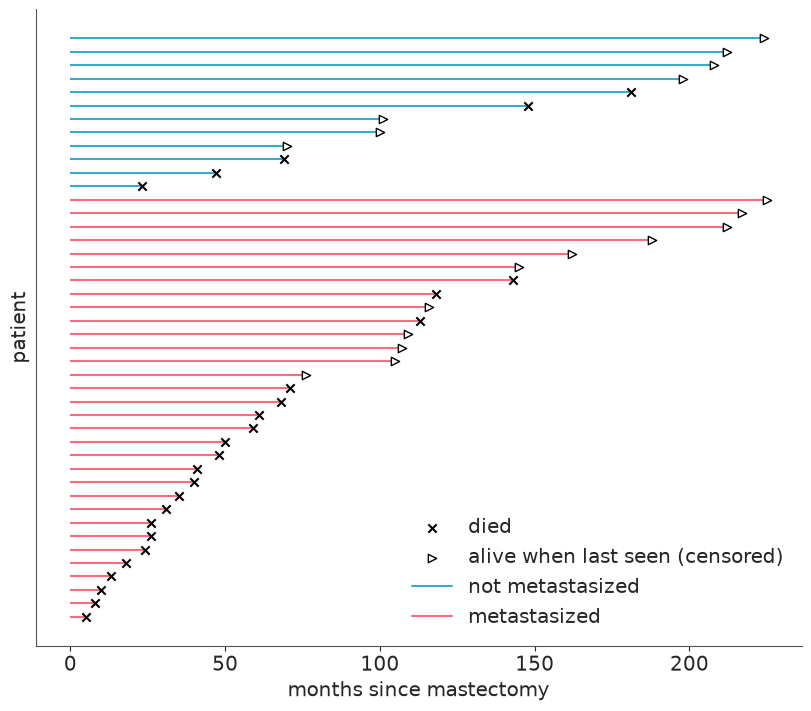

In [3]:
order = df.sort_values(["group", "time"]).reset_index(drop=True)
colors = order.group.map({"not metastasized": "C0", "metastasized": "C1"})

fig, ax = plt.subplots(figsize=(8, 7))
ax.hlines(order.index, 0, order.time, color=colors, lw=1.5)
died = order[order.event]
alive = order[~order.event]
ax.scatter(died.time, died.index, marker="x", color="k", zorder=3, label="died")
ax.scatter(alive.time, alive.index, marker=">", facecolor="w", edgecolor="k", zorder=3,
           label="alive when last seen (censored)")
for name, color in [("not metastasized", "C0"), ("metastasized", "C1")]:
    ax.plot([], [], color=color, lw=1.5, label=name)
ax.set(xlabel="months since mastectomy", ylabel="patient", yticks=[])
ax.legend(loc="lower right");

Notice *who* is censored: mostly the long lines. Censored patients are not a random subset,
they are disproportionately the long survivors. Hold that thought.

## 2 · A model-free benchmark: Kaplan-Meier

The Kaplan-Meier (KM) estimator is the empirical survival function that respects
censoring. At each death time $t_j$ with $d_j$ deaths among the $n_j$ patients still under
observation, survival is multiplied by $(1 - d_j / n_j)$. Censored patients count in the
denominator $n_j$ for as long as they were observed and then silently leave. Ten lines of NumPy:

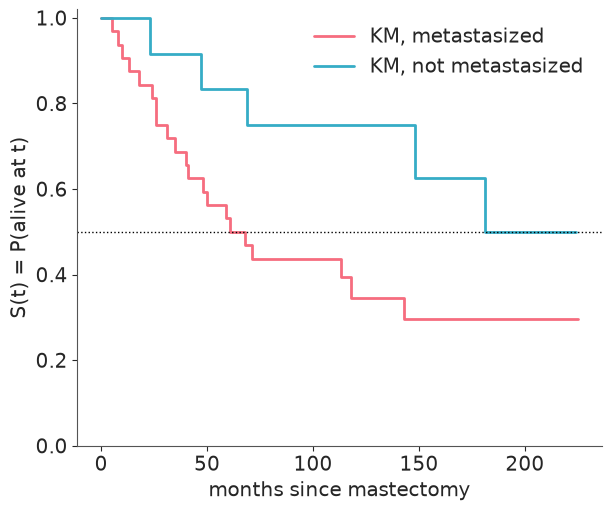

In [4]:
def kaplan_meier(time, event):
    """Kaplan-Meier estimate. Returns step-function knots (t, S), starting at (0, 1)."""
    time, event = np.asarray(time, dtype=float), np.asarray(event, dtype=bool)
    t_event = np.unique(time[event])
    at_risk = np.array([(time >= t).sum() for t in t_event])
    deaths = np.array([((time == t) & event).sum() for t in t_event])
    surv = np.cumprod(1 - deaths / at_risk)
    # extend the last step to the end of follow-up
    return np.r_[0, t_event, time.max()], np.r_[1, surv, surv[-1]]


GROUP_COLORS = {"not metastasized": "C0", "metastasized": "C1"}


def plot_km(ax):
    for name, grp in df.groupby("group"):
        ax.step(*kaplan_meier(grp.time, grp.event), where="post", color=GROUP_COLORS[name], lw=2,
                label=f"KM, {name}")
    ax.set(xlabel="months since mastectomy", ylabel="S(t) = P(alive at t)", ylim=(0, 1.02))


fig, ax = plt.subplots()
plot_km(ax)
ax.axhline(0.5, color="k", ls=":", lw=1)
ax.legend();

The metastasized group (red) reaches $S = 0.5$ after roughly 60-70 months. The other group
only touches 0.5 with its very last observed death, at 181 months, when just five women
were still under observation - a "median" that rests on a single event. KM also cannot
extrapolate beyond the last follow-up, has no smooth hazard, and offers no direct measure of
the group difference with uncertainty. That is what a parametric model buys - at the price
of assumptions we will have to check against this very curve.

## 3 · The likelihood of "not yet"

Let $T$ be the survival time with density $f$ and survival function $S(t) = P(T > t)$.

- A patient who **died** at $t_i$ contributes $f(t_i)$, as usual.
- A patient **censored** at $t_i$ contributes $P(T > t_i) = S(t_i)$: we saw that the event
  had not happened by $t_i$, nothing more.

`pm.Censored(name, dist, lower, upper, observed)` implements exactly this: an observed value
equal to the bound `upper` contributes $P(T \ge \text{upper})$, anything below it contributes
the density. `lower` and `upper` can be **arrays**, one bound per observation, which is the
whole trick:

- censored row: `upper` = her follow-up time (so the observed value sits *on* the bound);
- death: `upper` = $\infty$ (no bound, ordinary density).

In [5]:
t = df.time.to_numpy(dtype=float)
event = df.event.to_numpy()
metastasized = (df.metastasized == "yes").to_numpy(dtype=int)
upper = np.where(event, np.inf, t)
X_MEAN = metastasized.mean()  # used to centre the covariate, see section 4

Do not take the idiom on trust. `pm.logp` lets us check it against SciPy for an arbitrary
Weibull: deaths should get `logpdf`, censored rows `logsf` (log survival function).

In [6]:
censored_dist = pm.Censored.dist(pm.Weibull.dist(alpha=1.5, beta=100.0), lower=None, upper=upper)
logp_pymc = pm.logp(censored_dist, t).eval()
logp_scipy = np.where(
    event,
    stats.weibull_min.logpdf(t, 1.5, scale=100.0),
    stats.weibull_min.logsf(t, 1.5, scale=100.0),
)
print("pm.Censored matches f(t) for deaths and S(t) for censored rows:", np.allclose(logp_pymc, logp_scipy))

pm.Censored matches f(t) for deaths and S(t) for censored rows: True


## 4 · An exponential AFT model

Start with the simplest survival distribution, the Exponential (constant hazard), and let
its scale depend on metastasis:

$$
T_i \sim \text{Exponential}(\text{scale} = \lambda_i), \qquad
\log \lambda_i = \alpha + \beta\,(\text{metastasized}_i - \bar{x})
$$

This is an **accelerated failure time** (AFT) model: the covariate stretches or shrinks the
time axis. $e^{\beta}$ is a **time ratio** - if $e^\beta = 0.5$, every quantile of survival
time (median included) is halved for metastasized patients, as if their clock ran twice as fast.

**Why centre a 0/1 covariate?** Only 12 women are in the reference group. With the raw
indicator, $\alpha$ would be informed by those 12 alone and every change in $\alpha$ would
have to be undone by $\beta$ for the other 32, so the two end up strongly correlated in the
posterior and the sampler works harder for the same answer. Subtracting the mean $\bar{x}$
(the share of metastasized patients) makes $\alpha$ the log scale of an "average" patient.
$\beta$ and its interpretation are untouched. Section 6 puts numbers on the difference.

**Priors.** `Normal(4.5, 1.5)` on $\alpha$ puts the typical median survival
($\lambda \ln 2$) around 5 years, with a 94% range from a few months to many decades.
$\beta \sim$ `Normal(0, 1)` says the time ratio is most likely between 1/7 and 7 and does
not presume the sign. We write one function so that the very same model can later be
fitted to mangled versions of the data.

Sampling: [alpha, beta, time]


prior median survival of a typical patient, months (3%, 50%, 97%): [   4.   62. 1073.]


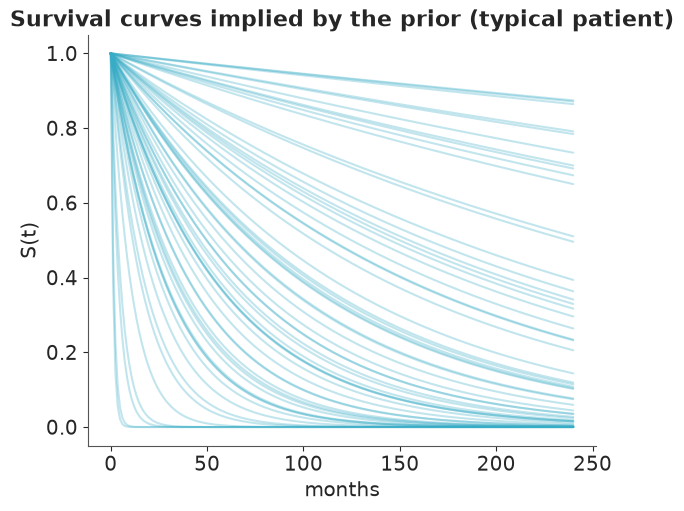

In [7]:
def fit_aft(family, time, upper, x, beta_sd=1.0, alpha_sd=1.5, prior_only=False, centre=True):
    """Censored AFT model. family is "exponential" or "weibull"."""
    with pm.Model(coords={"obs": np.arange(len(time))}) as model:
        upper_ = pm.Data("upper", upper, dims="obs")
        alpha = pm.Normal("alpha", 4.5, alpha_sd)
        beta = pm.Normal("beta", 0, beta_sd)
        scale = pm.math.exp(alpha + beta * (x - X_MEAN if centre else x))
        if family == "exponential":
            dist = pm.Exponential.dist(scale=scale)
        else:
            k = pm.LogNormal("k", 0, 0.5)
            dist = pm.Weibull.dist(alpha=k, beta=scale)
        pm.Deterministic("time_ratio", pm.math.exp(beta))
        pm.Censored("time", dist, lower=None, upper=upper_, observed=time, dims="obs")
        if prior_only:
            return model, pm.sample_prior_predictive(1000, random_seed=RANDOM_SEED)
        idata = pm.sample(random_seed=RANDOM_SEED)
    return model, idata


_, exp_prior = fit_aft("exponential", t, upper, metastasized, prior_only=True)

prior = az.extract(exp_prior, group="prior")
prior_median = np.exp(prior["alpha"].values) * np.log(2)
print("prior median survival of a typical patient, months (3%, 50%, 97%):",
      np.quantile(prior_median, [0.03, 0.5, 0.97]).round(0))

fig, ax = plt.subplots()
grid = np.linspace(0, 240, 200)
ax.plot(grid, np.exp(-grid[:, None] / np.exp(prior["alpha"].values[:60])), color="C0", alpha=0.3)
ax.set(xlabel="months", ylabel="S(t)", title="Survival curves implied by the prior (typical patient)");

From "almost everybody dies within the first year" to "nearly nine in ten are alive after
twenty": wide, but every curve is something that could happen after cancer surgery. Now fit.

In [8]:
exp_model, exp_idata = fit_aft("exponential", t, upper, metastasized)

print("divergences:", int(exp_idata.sample_stats["diverging"].sum()))
az.summary(exp_idata, ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [alpha, beta]


divergences: 0


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,5.11,0.20,4.74,5.49,4035.14,2496.64,1.0,0.00,0.00
beta,-0.79,0.44,-1.61,0.02,3742.69,2275.52,1.0,0.01,0.01
time_ratio,0.50,0.22,0.14,0.89,3742.69,2275.52,1.0,0.00,0.00


Clean diagnostics. Before interpreting, the promised demonstration.

## 5 · What happens if you ignore censoring

Two tempting shortcuts, each fitted with the *same* model and priors:

- **drop**: keep only the 26 women whose death was observed ("we only know the true time for them");
- **pretend**: keep everyone but treat censored follow-up times as death times.

In [9]:
no_bound = np.full(len(t), np.inf)
_, drop_idata = fit_aft("exponential", t[event], no_bound[event], metastasized[event])
_, pretend_idata = fit_aft("exponential", t, no_bound, metastasized)

NUTS[nutpie]: [alpha, beta]


NUTS[nutpie]: [alpha, beta]


In [10]:
def scale_draws(post, x):
    """Posterior draws of the scale parameter for metastasis indicator x (0 or 1)."""
    return np.exp(post["alpha"].values + post["beta"].values * (x - X_MEAN))


def median_survival(idata):
    """Posterior draws of median survival (months) per group, for either family."""
    post = az.extract(idata)
    k = post["k"].values if "k" in post else 1.0
    return {
        name: scale_draws(post, x) * np.log(2) ** (1 / k)
        for name, x in [("not metastasized", 0), ("metastasized", 1)]
    }


rows = {}
for label, idata in [("censored (correct)", exp_idata), ("drop censored rows", drop_idata),
                     ("pretend censored = died", pretend_idata)]:
    for name, draws in median_survival(idata).items():
        lo, mid, hi = np.quantile(draws, [0.03, 0.5, 0.97])
        rows[(label, name)] = {"median survival (months)": mid, "3%": lo, "97%": hi}
bias_table = pd.DataFrame(rows).T.round(0)
bias_table

median survival (months)     3%  \
censored (correct)      not metastasized                     199.0  101.0   
                        metastasized                          92.0   63.0   
drop censored rows      not metastasized                      61.0   32.0   
                        metastasized                          35.0   24.0   
pretend censored = died not metastasized                      90.0   56.0   
                        metastasized                          59.0   43.0   

                                            97%  
censored (correct)      not metastasized  455.0  
                        metastasized      142.0  
drop censored rows      not metastasized  141.0  
                        metastasized       53.0  
pretend censored = died not metastasized  155.0  
                        metastasized       83.0

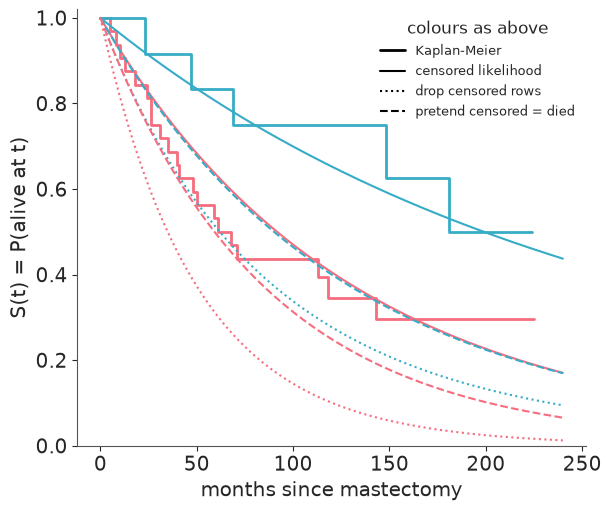

In [11]:
fits = [("censored likelihood", exp_idata, "-"), ("drop censored rows", drop_idata, ":"),
        ("pretend censored = died", pretend_idata, "--")]

fig, ax = plt.subplots()
plot_km(ax)
for label, idata, ls in fits:
    post = az.extract(idata)
    for x, color in [(0, "C0"), (1, "C1")]:
        ax.plot(grid, np.exp(-grid[:, None] / scale_draws(post, x)).mean(axis=1), color=color, ls=ls)
handles = [Line2D([], [], color="k", lw=2, drawstyle="steps-post", label="Kaplan-Meier")]
handles += [Line2D([], [], color="k", ls=ls, label=label) for label, _, ls in fits]
ax.legend(handles=handles, fontsize=9, title="colours as above");

Both shortcuts are badly **pessimistic**, and the posterior intervals give no warning:

- **Dropping** censored rows throws away precisely the long survivors (remember the line
  plot). The estimated median survival falls to 30-40% of the correct one, and the dotted
  curves sit far below the Kaplan-Meier steps.
- **Pretending** is milder but biased the same way - median survival comes out at roughly
  45-65% of the correct value - because every "she was alive at 150 months" is recorded
  as "she died at 150 months".

Only the censored likelihood (solid) tracks the KM curves. The bias grows with the censored
fraction, which is why it is worst for the non-metastasized group (7 of 12 censored). It is
also as large as the effect we are trying to measure: the "pretend" curve for women
*without* metastasis (dashed blue) lies almost exactly on top of the correct curve for women
*with* it (solid red).

## 6 · Is the hazard constant? A Weibull model

The Exponential has a constant hazard: the risk of dying next month is the same 6 months
and 10 years after surgery. The Weibull adds a shape $k$:

$$S(t) = \exp\!\big(-(t/\lambda)^k\big), \qquad h(t) \propto t^{\,k-1}$$

$k < 1$ means the hazard falls with time, $k > 1$ that it rises, and $k = 1$ is the
Exponential. In PyMC's `pm.Weibull(alpha, beta)` the shape is `alpha` and the scale is `beta`
(do not confuse them with our regression coefficients). The AFT reading of $e^\beta$ as a
time ratio is unchanged. The prior `LogNormal(0, 0.5)` centres $k$ on 1 and covers 0.4-2.6.

In [12]:
wei_model, wei_idata = fit_aft("weibull", t, upper, metastasized)

print("divergences:", int(wei_idata.sample_stats["diverging"].sum()))
az.summary(wei_idata, ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [alpha, beta, k]


divergences: 0


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,5.15,0.23,4.73,5.58,3004.01,2389.75,1.0,0.00,0.00
beta,-0.78,0.46,-1.60,0.15,3673.78,2581.21,1.0,0.01,0.01
k,0.91,0.14,0.66,1.19,3241.86,2742.84,1.0,0.00,0.00
time_ratio,0.51,0.24,0.14,0.94,3673.78,2581.21,1.0,0.00,0.01


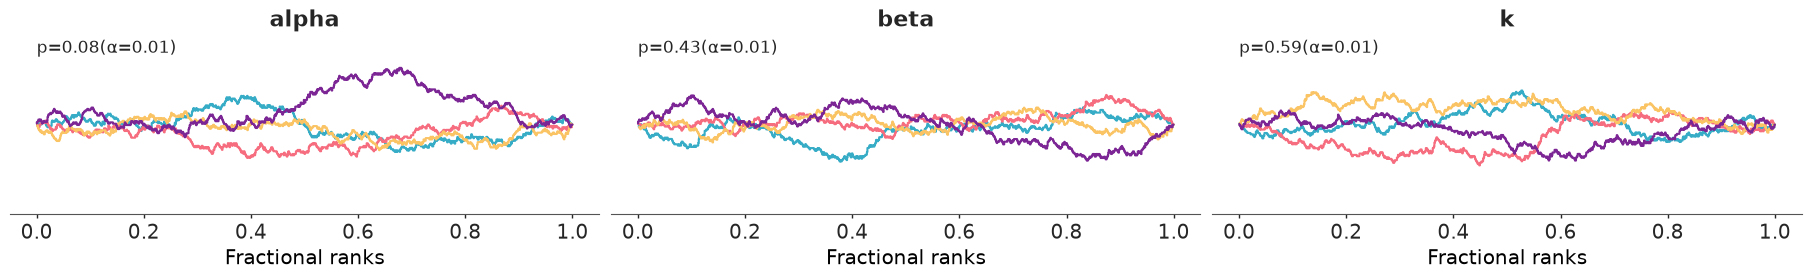

In [13]:
az.plot_rank(wei_idata, var_names=["alpha", "beta", "k"]);

`r_hat` of 1.00, ESS in the thousands, and the uniformity test printed in each rank plot
flags nothing. The shape $k$ is estimated a little below 1 with an interval that
comfortably includes 1: no evidence against a constant hazard, which the formal comparison
below confirms.

### Aside: what centring bought us

The same model with the raw 0/1 indicator, for comparison:

In [14]:
_, raw_idata = fit_aft("weibull", t, upper, metastasized, centre=False)

centring = {}
for label, idata in [("centred", wei_idata), ("raw 0/1 indicator", raw_idata)]:
    post = az.extract(idata)
    ess = az.ess(idata, var_names=["alpha", "beta"])
    centring[label] = {
        "corr(alpha, beta)": np.corrcoef(post["alpha"], post["beta"])[0, 1],
        "ess_bulk alpha": float(ess["alpha"]),
        "ess_bulk beta": float(ess["beta"]),
    }
pd.DataFrame(centring).T.round(2)

NUTS[nutpie]: [alpha, beta, k]


,"corr(alpha, beta)",ess_bulk alpha,ess_bulk beta
centred,-0.07,3004.01,3673.78
raw 0/1 indicator,-0.83,1227.73,1227.30


Uncentred, $\alpha$ and $\beta$ have a posterior correlation of about -0.8 and the same 4000
draws are worth well under half as many effective draws. Nothing breaks in a model this
small - `r_hat` is still fine - but the habit pays off in larger regressions, where correlated
intercepts and slopes are a common cause of slow sampling.

### Survival curves with uncertainty

$S(t)$ is a deterministic function of the parameters, so each posterior draw gives a whole
curve; quantiles across draws give the band.

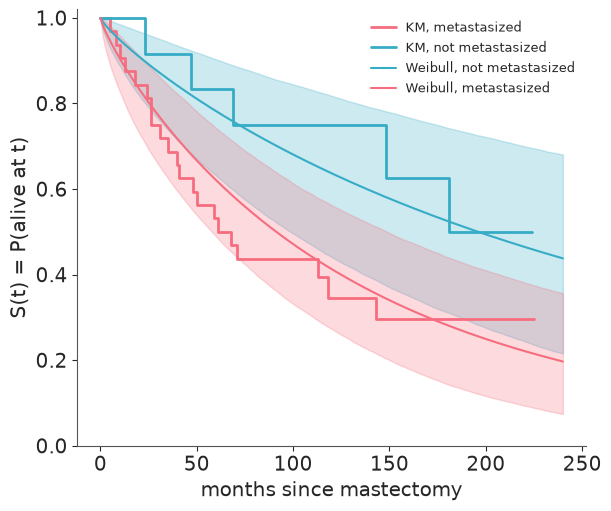

In [15]:
def survival_curves(idata, x, grid):
    """Array (draws, len(grid)) of S(t) for a patient with metastasis indicator x."""
    post = az.extract(idata)
    k = post["k"].values[:, None] if "k" in post else 1.0
    scale = scale_draws(post, x)[:, None]
    return np.exp(-((grid / scale) ** k))


fig, ax = plt.subplots()
plot_km(ax)
for x, color, name in [(0, "C0", "not metastasized"), (1, "C1", "metastasized")]:
    curves = survival_curves(wei_idata, x, grid)
    lo, hi = np.quantile(curves, [0.03, 0.97], axis=0)
    ax.fill_between(grid, lo, hi, color=color, alpha=0.25)
    ax.plot(grid, curves.mean(axis=0), color=color, label=f"Weibull, {name}")
ax.legend(fontsize=9);

The KM steps stay inside the 94% bands, except that the non-metastasized curve starts a touch
above its band: nobody in that group of 12 died in the first 23 months, which a handful of
patients can easily do by chance. The bands are **wide** - this is
what 44 patients and 26 deaths can tell you - and widest for the small non-metastasized
group, whose curve is informed by only 5 deaths.

### A posterior predictive check made for censored data

A standard PPC compares observed and replicated outcomes, but our observed `time` mixes
deaths with censoring times, so a density overlay would compare apples with oranges.
`az.plot_ppc_censored` does the right thing: it draws the **Kaplan-Meier curve of the
observed data** against the survival curves of replicated datasets. It needs three things:

1. *Uncensored* replicated times. Draws from `pm.Censored` are clipped at `upper`, so we
   first lift the bound - this is why `upper` was registered with `pm.Data`.
2. An event indicator (1 = event, 0 = censored) in `constant_data`, under the **same name**
   as the observed variable.
3. `extrapolation_factor=None`. The default (1.2) *discards* replicated times beyond 1.2x
   the longest follow-up and renormalises, which drags every replicated curve down to zero
   at that point. With heavy censoring that makes a good model look bad. We keep all draws
   and simply zoom the axis instead.

Sampling: [time]


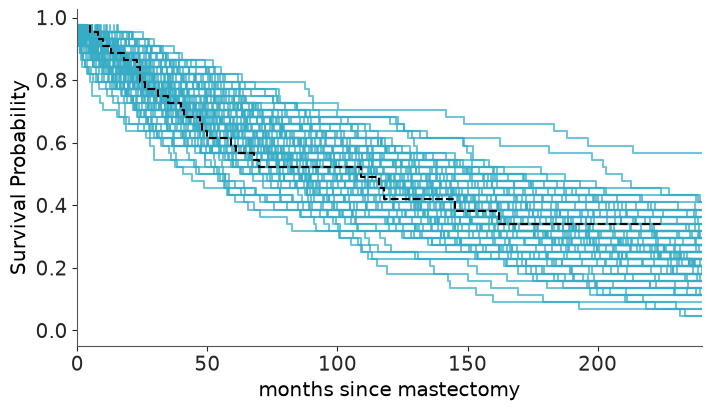

In [16]:
with wei_model, warnings.catch_warnings():
    # PyTensor compares old and new data values and grumbles about inf - inf; harmless
    warnings.simplefilter("ignore", RuntimeWarning)
    pm.set_data({"upper": no_bound})
    wei_ppc = pm.sample_posterior_predictive(wei_idata, random_seed=RANDOM_SEED)
    pm.set_data({"upper": upper})

wei_ppc["constant_data"] = wei_ppc["constant_data"].to_dataset().assign(time=("obs", event.astype(int)))
az.plot_ppc_censored(wei_ppc, var_names="time", num_samples=100, extrapolation_factor=None)
plt.gcf().set_size_inches(7, 4)
plt.gcf().axes[0].set(xlim=(0, 240), xlabel="months since mastectomy");

The observed KM curve (dashed, both groups pooled) runs through the middle of the replicated
curves. Nothing here or in the per-group plot above argues against the Weibull AFT model.

## 7 · Interpret: time ratio and median survival

In [17]:
post = az.extract(wei_idata)
time_ratio = post["time_ratio"].values
print(f"time ratio exp(beta): median {np.median(time_ratio):.2f}, "
      f"94% interval {np.quantile(time_ratio, [0.03, 0.97]).round(2)}")
print(f"P(metastasis shortens survival) = {(time_ratio < 1).mean():.2f}")

medians = median_survival(wei_idata)
for name, draws in medians.items():
    print(f"median survival, {name:<17}: {np.median(draws):4.0f} months, "
          f"94% interval {np.quantile(draws, [0.03, 0.97]).round(0)}, "
          f"P(beyond end of follow-up) = {(draws > t.max()).mean():.2f}")

time ratio exp(beta): median 0.46, 94% interval [0.18 1.05]
P(metastasis shortens survival) = 0.96
median survival, not metastasized :  197 months, 94% interval [ 99. 462.], P(beyond end of follow-up) = 0.36
median survival, metastasized     :   91 months, 94% interval [ 58. 149.], P(beyond end of follow-up) = 0.00


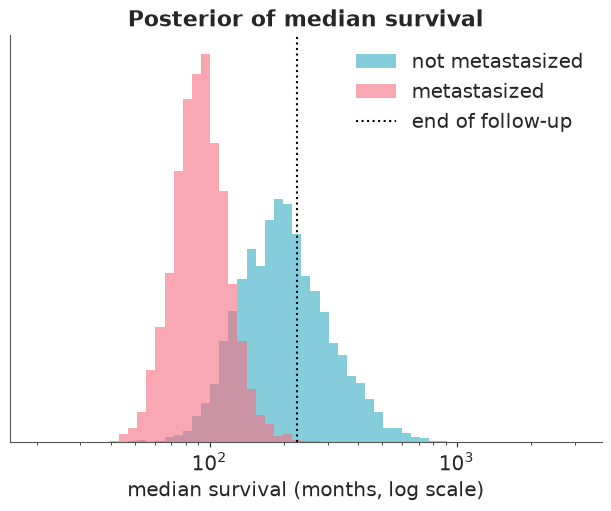

In [18]:
fig, ax = plt.subplots()
bins = np.geomspace(20, 3000, 60)
for name, draws in medians.items():
    ax.hist(draws, bins=bins, color=GROUP_COLORS[name], alpha=0.6, label=name)
ax.axvline(t.max(), color="k", ls=":", label="end of follow-up")
ax.set(xscale="log", xlabel="median survival (months, log scale)", yticks=[],
       title="Posterior of median survival")
ax.legend();

Metastasized cancer roughly **halves** survival time, and the posterior probability that
it shortens survival at all is high (about 0.96) but not overwhelming. The median survival of
metastasized patients is pinned down reasonably well because we watched more than half of
them die. For the other group more than a third of the posterior lies **beyond the end of
follow-up**: that number is an extrapolation resting on the Weibull shape, not on data.
Kaplan-Meier's median rested on a single death; the parametric model answers with a
(rightly) huge interval.

## 8 · Exponential or Weibull?

LOO works unchanged: the pointwise log-likelihood of a censored row is simply $\log S(t_i)$.

In [19]:
with exp_model:
    pm.compute_log_likelihood(exp_idata, progressbar=False)
with wei_model:
    pm.compute_log_likelihood(wei_idata, progressbar=False)

az.compare({"exponential": exp_idata, "weibull": wei_idata})

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
exponential,0,0.0,0.00,NaN,,,2.1,-160.0,15.0,1.0
weibull,1,-0.5,0.45,0.86,N < 100,,2.3,-160.0,15.0,0.0


Less than one `elpd` point apart. The simpler Exponential is marginally ahead because the
Weibull's extra parameter buys nothing, but a gap this small (note ArviZ's `N < 100` flag
on the difference) is no reason to prefer either. With 26 events there is no information to
distinguish $k = 0.9$ from $k = 1$. We keep the Weibull for reporting, because its intervals
honestly include our ignorance about the hazard shape.

## 9 · Small data: how much is the prior doing?

With 26 deaths the prior cannot be an afterthought. `az.psense_summary` perturbs the prior
and the likelihood by raising each to a power slightly different from 1 and measures how
far the posterior moves (it needs the `log_prior` and `log_likelihood` groups). Values above
0.05 flag sensitivity.

In [20]:
with wei_model:
    pm.stats.compute_log_prior(wei_idata, progressbar=False)

az.psense_summary(wei_idata, var_names=["alpha", "beta", "k"])

We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


,prior,likelihood,diagnosis
alpha,0.019,0.103,✓
beta,0.074,0.094,potential prior-data conflict
k,0.011,0.071,✓


`beta` - the one parameter the clinical question is about - is flagged: its posterior
responds to the prior *and* to the likelihood. ArviZ words this as a "potential prior-data
conflict", but read it for what the numbers say: with 12 patients in one group, a
`Normal(0, 1)` prior is informative enough to matter. `alpha` and `k` are not
prior-sensitive. A diagnostic flag is a prompt to look, so look:
refit with a much tighter and a much wider prior on $\beta$ and compare the quantity we care about.

In [21]:
sens = {}
for beta_sd in [0.3, 1.0, 5.0]:
    idata = wei_idata if beta_sd == 1.0 else fit_aft("weibull", t, upper, metastasized, beta_sd=beta_sd)[1]
    ratio = az.extract(idata, var_names="time_ratio").values
    lo, mid, hi = np.quantile(ratio, [0.03, 0.5, 0.97])
    sens[f"beta ~ Normal(0, {beta_sd})"] = {
        "time ratio (median)": mid, "3%": lo, "97%": hi, "P(ratio < 1)": (ratio < 1).mean()
    }
pd.DataFrame(sens).T.round(2)

NUTS[nutpie]: [alpha, beta, k]


NUTS[nutpie]: [alpha, beta, k]


,time ratio (median),3%,97%,P(ratio < 1)
"beta ~ Normal(0, 0.3)",0.77,0.47,1.24,0.84
"beta ~ Normal(0, 1.0)",0.46,0.18,1.05,0.96
"beta ~ Normal(0, 5.0)",0.36,0.09,0.96,0.97


Read the table from the middle row outwards. A sceptical prior (`sd = 0.3`, "metastasis
changes survival time by at most a factor of two or so") pulls the time ratio clearly
towards 1 and leaves real doubt about the sign; a nearly flat prior (`sd = 5`) lets the
ratio drift further from 1 than our default. The *direction* of the effect is the same
under every prior, its *size* ranges from roughly a quarter off to almost two thirds off
survival time. That is the honest summary of a 44-patient study, and it is the reason a
Bayesian analysis of small survival data should always state its priors and show this table.

### Try it yourself

1. Replace the Weibull with a **log-normal** AFT model (`pm.LogNormal.dist(mu=alpha + beta * x,
   sigma=sigma)`). Its hazard rises and then falls. Does LOO prefer it? Do the median
   survival estimates for the non-metastasized group change, and why is that group so
   sensitive to the choice of family?
2. Let the Weibull shape differ by group (`k` with `dims="group"`). The KM curves hint that
   the groups might differ in hazard *shape* - is there enough data to tell?
3. Artificially censor the data further: pretend the study had stopped at 100 months (every
   `time > 100` becomes a censored observation at 100). How much wider do the posteriors of
   the time ratio and of median survival become, and how much worse do the two naive
   shortcuts of section 5 get?

Next: challenge **C04** applies all of this to 7,000 telecom customers, most of whom have
not churned *yet*.